# Lecture 08b — Change, disturbance, and the price of a tonne

**AI-integrated Sustainable Finance (25881) · Lecture 8 lab, part 2 of 2**

Notebook 08a stopped at an index. That is where most remote-sensing tutorials stop, and it is
where the finance question begins. A map of dNBR is not an input to anything. **Tonnes** are.

This notebook walks the rest of the chain and, at each step, keeps the uncertainty rather than
discarding it:

$$\text{two scenes} \;\rightarrow\; \text{dNBR} \;\rightarrow\; \text{hectares by severity}
\;\rightarrow\; \text{tonnes CO}_2\text{e} \;\rightarrow\; \text{dollars}$$

The finding at the end is not a number. It is that the **interval is wider than the price
signal it is meant to inform** — and that this is a fact about the world, not a failure of
effort. Learning to report that honestly is the point of the exercise.

**Prerequisite:** notebook 08a. This one assumes you know what a band and an index are.

In [1]:
# --- dependencies ----------------------------------------------------------
# Checked against the teaching environment `Python2026_31314` on 1 September
# 2026: numpy, pandas, matplotlib, geopy and ipywidgets are already there; the
# geospatial stack is not. This cell tells you exactly what to run. It does not
# install anything for you unless you are on Colab.
import importlib, sys

REQUIRED = {"numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib",
            "xarray": "xarray", "rasterio": "rasterio", "rioxarray": "rioxarray",
            "pystac_client": "pystac-client", "odc.stac": "odc-stac"}
OPTIONAL = {"geopy": "geopy", "ipyleaflet": "ipyleaflet"}

def _missing(d):
    out = []
    for mod, pkg in d.items():
        try:
            importlib.import_module(mod)
        except Exception:
            out.append(pkg)
    return out

need, nice_to_have = _missing(REQUIRED), _missing(OPTIONAL)
IN_COLAB = "google.colab" in sys.modules

if need and IN_COLAB:
    import subprocess
    print("Colab detected. Installing:", " ".join(need))
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", *need], check=False)
    print("Done. If imports still fail, restart the runtime and re-run.")
elif need:
    print("Missing required packages:", " ".join(need))
    print()
    print("  Anaconda :  conda install -c conda-forge " + " ".join(need))
    print("  pip      :  pip install " + " ".join(need))
    print()
    print("Install, restart the kernel, then re-run this cell.")
else:
    print("All required packages present.")

if nice_to_have:
    print(f"Optional (the notebook works without them): {' '.join(nice_to_have)}")


All required packages present.


In [2]:
import pathlib, urllib.request
HELPER = "esgsat.py"
REPO_RAW = ("https://raw.githubusercontent.com/VitaliAlexeev/"
            "AI_SustainableFinance_2026/main/helpers/esgsat.py")
if not pathlib.Path(HELPER).exists():
    try:
        urllib.request.urlretrieve(REPO_RAW, HELPER)
        print("Downloaded esgsat.py.")
    except Exception as exc:
        print(f"Could not download esgsat.py ({type(exc).__name__}). Place it beside this notebook.")

import numpy as np
import matplotlib.pyplot as plt
import esgsat as E

USE_LIVE = True
RESOLUTION_M = 20

np.seterr(divide="ignore", invalid="ignore")
plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(25881)
print("Ready.")

Ready.


## 1. The question

Pick a concrete one, because a vague question produces a vague interval.

> *A forest carbon project holds credits over an area that burnt. How many tonnes were lost,
> and what is the exposure worth?*

This is reversal risk, and it is the single largest source of loss in nature-based carbon
projects. A credit issued for stored carbon is only as durable as the storage.

We will answer it in the way an analyst actually has to: from two satellite images, published
emission factors, and an honest account of what we do not know.

In [3]:
# Area and dates. The defaults use a well-documented Australian fire ground.
AOI_NAME = "blue-mountains"
HALF_WIDTH_KM = 15.0

PRE_START,  PRE_END  = "2019-09-01", "2019-11-15"   # before
POST_START, POST_END = "2020-02-01", "2020-04-15"   # after
MAX_CLOUD = 20.0

BBOX = E.bbox_from_place(AOI_NAME, HALF_WIDTH_KM, use_network=False)
print(f"Area  : {E.PRESET_AOIS[AOI_NAME][3]}")
print(f"BBox  : {tuple(round(v, 4) for v in BBOX)}")
print(f"Pre   : {PRE_START} to {PRE_END}")
print(f"Post  : {POST_START} to {POST_END}")

Area  : Blue Mountains, 2019-20 fire ground
BBox  : (np.float64(150.1376), -33.8351, np.float64(150.4624), -33.5649)
Pre   : 2019-09-01 to 2019-11-15
Post  : 2020-02-01 to 2020-04-15


## 2. Two scenes, one place

Change detection needs a matched pair. Three things must line up, and each is a place where a
result quietly dies:

- **Geometry.** A one-pixel misregistration manufactures change along every edge in the scene.
  At 20 m, that is a 20 m-wide band of false "change" around every road, river and paddock
  boundary.
- **Processing level.** Comparing a Level-1C scene with a Level-2A scene compares
  top-of-atmosphere with surface reflectance. The difference is atmosphere, not change.
- **Season.** Australian vegetation looks different in February and September for reasons that
  have nothing to do with fire. Matching the season is not optional.

If the live path is unavailable, the fallback is a synthetic pair: an unburnt scene and a burnt
one, with cloud added to the **post** scene only. That asymmetry is deliberate, and section 4
is about what it does to you.

In [4]:
def get_scene(bbox, start, end, max_cloud, synthetic_kwargs):
    '''Return (scene dict, label). Falls through to synthetic on any failure.'''
    if USE_LIVE:
        try:
            items = E.search_scenes(bbox, start, end, max_cloud=max_cloud)
            if items:
                ds = E.load_bands(items[0], bbox,
                                  bands=["B03", "B04", "B08", "B11", "B12"],
                                  resolution=RESOLUTION_M)
                sc = {b: ds[b].isel(time=0).values for b in ["B03", "B04", "B08", "B11", "B12"]}
                sc["SCL"] = ds["scl"].isel(time=0).values
                return sc, f"live {str(ds.time.values[0])[:10]} (cloud "\
                           f"{items[0].properties.get('eo:cloud_cover', float('nan')):.0f}%)"
        except Exception as exc:
            print(f"  live path unavailable: {type(exc).__name__}: {exc}")
    return E.demo_scene(size=320, as_dn=True, **synthetic_kwargs), "synthetic"

print("Pre-event scene:")
pre_raw,  pre_label  = get_scene(BBOX, PRE_START,  PRE_END,  MAX_CLOUD,
                                 dict(burnt=False, cloud=False))
print(f"  -> {pre_label}")
print("Post-event scene:")
post_raw, post_label = get_scene(BBOX, POST_START, POST_END, MAX_CLOUD,
                                 dict(burnt=True,  cloud=True))
print(f"  -> {post_label}")

assert pre_raw["B08"].shape == post_raw["B08"].shape, \
    "Scenes differ in shape. Reproject or clip to a common grid before continuing."

pre  = {b: E.to_reflectance(pre_raw[b])  for b in pre_raw  if b != "SCL"}
post = {b: E.to_reflectance(post_raw[b]) for b in post_raw if b != "SCL"}
pre["SCL"], post["SCL"] = pre_raw["SCL"], post_raw["SCL"]
print(f"\nGrid: {pre['B08'].shape}, {RESOLUTION_M} m pixels, "
      f"{E.pixel_area_ha(RESOLUTION_M)} ha each")

Pre-event scene:


C:\Users\Vitali\anaconda3\envs\Python2026_31314\Lib\site-packages\pystac\extensions\storage.py:724: UserWarning: Could not parse bucket/account from href. The following assets were not migrated: ['red', 'green', 'blue', 'visual', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededge1', 'swir16', 'wvp', 'nir08', 'scl', 'aot', 'coastal', 'nir09', 'cloud', 'snow', 'preview', 'granule_metadata', 'tileinfo_metadata', 'product_metadata', 'thumbnail']
  warnings.warn(


  -> live 2019-11-06 (cloud 0%)
Post-event scene:


C:\Users\Vitali\anaconda3\envs\Python2026_31314\Lib\site-packages\pystac\extensions\storage.py:724: UserWarning: Could not parse bucket/account from href. The following assets were not migrated: ['red', 'green', 'blue', 'visual', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededge1', 'swir16', 'wvp', 'nir08', 'scl', 'aot', 'coastal', 'nir09', 'cloud', 'snow', 'preview', 'granule_metadata', 'tileinfo_metadata', 'product_metadata', 'thumbnail']
  warnings.warn(


  -> live 2020-03-20 (cloud 0%)

Grid: (1540, 1546), 20 m pixels, 0.04 ha each


## 3. NBR and dNBR

Burnt vegetation loses near-infrared reflectance (structure destroyed) and gains shortwave
infrared (char, ash, exposed soil, water removed). NBR is built to exploit exactly that:

$$\text{NBR} = \frac{\rho_{\text{NIR}} - \rho_{\text{SWIR2}}}{\rho_{\text{NIR}} + \rho_{\text{SWIR2}}}
\qquad \text{Sentinel-2: } \frac{B08 - B12}{B08 + B12}$$

$$\text{dNBR} = \text{NBR}_{\text{pre}} - \text{NBR}_{\text{post}}$$

Positive dNBR means vegetation was lost. Note that dNBR is a **difference of two ratios**, so
every error in either scene propagates into it, and errors that are common to both scenes
cancel. That cancellation is the reason change detection is often more reliable than
single-date estimation — and the reason a mismatched pair is so destructive.

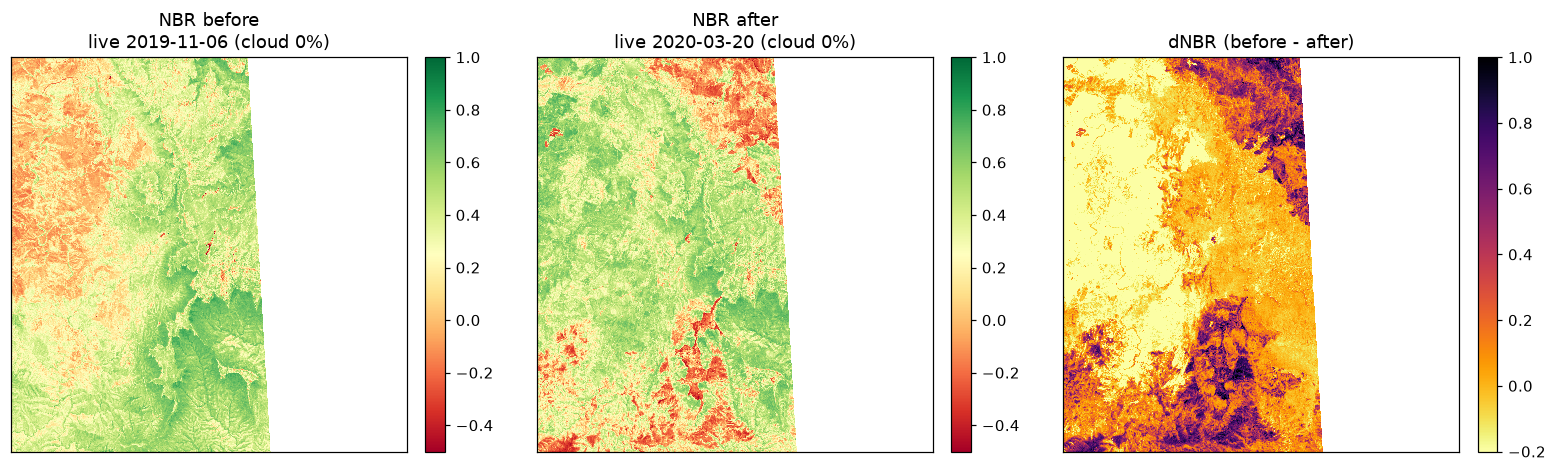

dNBR range  : -1.387 to +1.226
dNBR median : -0.012


In [5]:
nbr_pre  = E.nbr(pre["B08"],  pre["B12"])
nbr_post = E.nbr(post["B08"], post["B12"])
d_raw    = E.dnbr(nbr_pre, nbr_post)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))
E.show_index(nbr_pre,  f"NBR before\n{pre_label}",  ax=axes[0], vmin=-0.5, vmax=1.0)
E.show_index(nbr_post, f"NBR after\n{post_label}",  ax=axes[1], vmin=-0.5, vmax=1.0)
E.show_index(d_raw, "dNBR (before - after)", cmap="inferno_r", ax=axes[2], vmin=-0.2, vmax=1.0)
plt.tight_layout(); plt.show()

print(f"dNBR range  : {np.nanmin(d_raw):+.3f} to {np.nanmax(d_raw):+.3f}")
print(f"dNBR median : {np.nanmedian(d_raw):+.3f}")

## 4. The trap: cloud becomes "change"

Look at the dNBR panel again. If a cloud sits over the post scene and not the pre scene, the
cloud has high NIR and moderate SWIR, so its NBR is low, so **dNBR is large and positive**
exactly where the cloud is. The algorithm cannot tell the difference between a burnt forest and
a cloud, because in this feature space they look similar.

This is not a hypothetical. It is the single most common defect in student change-detection
work, and it appears in published work too. The fix is one line, and it must be applied to
**both** dates.

pixels dropped by the joint mask :  39.0%
of the whole scene, pixels that would have been called 'burnt'
  but are actually cloud or shadow :  0.72%

spurious burnt area if unmasked   :    688.4 ha
burnt area after masking          :  10485.5 ha
overstatement                     :      6.6%


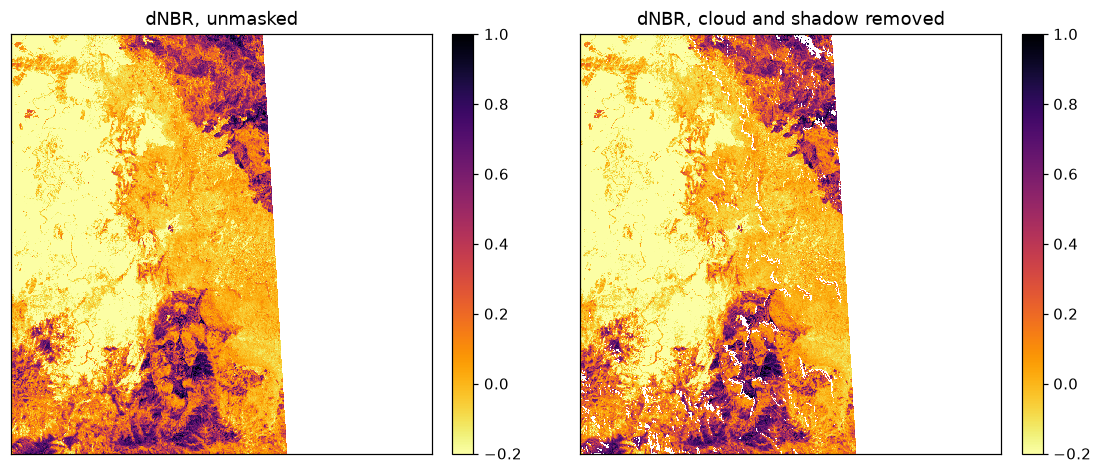

In [6]:
mask = E.scl_mask(pre["SCL"]) & E.scl_mask(post["SCL"])
d = np.where(mask, d_raw, np.nan)

lost = float(1.0 - mask.mean())
false_positive = float(np.nanmean((d_raw > 0.27) & ~mask))
print(f"pixels dropped by the joint mask : {lost*100:5.1f}%")
print(f"of the whole scene, pixels that would have been called 'burnt'")
print(f"  but are actually cloud or shadow : {false_positive*100:5.2f}%")

area_false = false_positive * d_raw.size * E.pixel_area_ha(RESOLUTION_M)
area_true  = float(np.nansum(d > 0.27)) * E.pixel_area_ha(RESOLUTION_M)
print(f"\nspurious burnt area if unmasked   : {area_false:8.1f} ha")
print(f"burnt area after masking          : {area_true:8.1f} ha")
if area_true > 0:
    print(f"overstatement                     : {area_false/area_true*100:8.1f}%")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.5, 4.4))
E.show_index(d_raw, "dNBR, unmasked", cmap="inferno_r", ax=a1, vmin=-0.2, vmax=1.0)
E.show_index(d,     "dNBR, cloud and shadow removed", cmap="inferno_r", ax=a2, vmin=-0.2, vmax=1.0)
plt.tight_layout(); plt.show()

## 5. Severity classes, and the threshold nobody defends

To get from a continuous dNBR surface to hectares, you must classify — and to classify, you
must choose cut-offs. The breaks below follow the widely used FIREMON convention.

Here is the uncomfortable part. **Those thresholds were calibrated for North American conifer
systems.** They are applied to Australian eucalypt forest constantly, including in work that
informs policy, usually without comment. Eucalypts resprout from epicormic buds, so a stand
that reads as high severity may be substantially alive.

Exercise C2 asks you to quantify what the choice costs. For now, notice that a *threshold* is a
modelling decision dressed as a measurement.

code  class                         pixels    hectares   share
--------------------------------------------------------------
  -1  No data / masked              928754     37150.2   39.0%
   0  Unburnt                      1006662     40266.5   42.3%
   1  Low severity                  183286      7331.4    7.7%
   2  Moderate-low severity         105609      4224.4    4.4%
   3  Moderate-high severity        107718      4308.7    4.5%
   4  High severity                  48811      1952.4    2.1%
--------------------------------------------------------------
      TOTAL                                    95233.6

Burnt area (severity class 1 and above): 17,817.0 ha


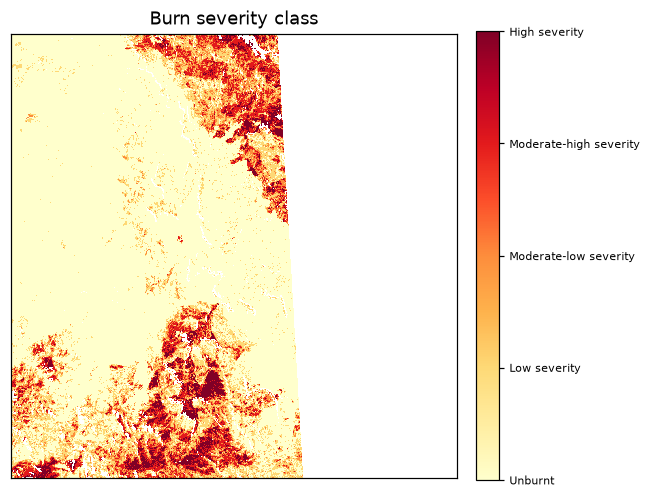

In [7]:
sev = np.where(np.isfinite(d), E.dnbr_severity(d), np.nan)
labels = {i: lab for i, (_, _, lab) in enumerate(E.DNBR_BREAKS)}

rows = E.class_areas(sev, RESOLUTION_M, labels)
total_ha = sum(r[3] for r in rows)
print(f"{'code':>4s}  {'class':<26s} {'pixels':>9s} {'hectares':>11s} {'share':>7s}")
print("-" * 62)
for code, lab, n, ha in rows:
    print(f"{code:4d}  {lab:<26s} {n:9d} {ha:11.1f} {ha/total_ha*100:6.1f}%")
print("-" * 62)
print(f"{'':4s}  {'TOTAL':<26s} {'':9s} {total_ha:11.1f}")

burnt_rows = [r for r in rows if r[0] >= 1]
BURNT_HA = sum(r[3] for r in burnt_rows)
print(f"\nBurnt area (severity class 1 and above): {BURNT_HA:,.1f} ha")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(sev, cmap="YlOrRd", vmin=0, vmax=4, interpolation="nearest")
ax.set_title("Burn severity class"); ax.set_xticks([]); ax.set_yticks([])
cb = fig.colorbar(im, ax=ax, ticks=range(5), fraction=0.046, pad=0.04)
cb.ax.set_yticklabels([labels[i] for i in range(5)], fontsize=7)
plt.tight_layout(); plt.show()

## 6. From hectares to tonnes

The IPCC Tier 1 method for fire is

$$L_{\text{fire}} = A \times M_B \times C_f \times G_{ef} \times 10^{-3}$$

| Symbol | Meaning | Units | Comes from |
|---|---|---|---|
| $A$ | burnt area | ha | **the satellite** |
| $M_B$ | mass of fuel available | t dry matter per ha | fuel inventory, literature |
| $C_f$ | combustion factor | fraction | literature, fire behaviour |
| $G_{ef}$ | emission factor | g gas per kg dry matter | IPCC tables, field campaigns |

**Only the first row came from the imagery.** The other three come from literature, and they
are where the uncertainty lives.

> **Read this before you run the next cell.** `esgsat.fire_emissions()` has **no defaults** for
> $M_B$, $C_f$ and $G_{ef}$. That is deliberate. Sourcing and justifying each parameter for the
> specific vegetation type is the analytical work; typing a number someone else picked is not.
> `E.FIRE_PARAMETERS_INDICATIVE` gives plausible **ranges** to start from, and names the tables
> to check them against — it is a starting point for your reading, not a citation.

In [8]:
for k, (lo, hi, meaning) in E.FIRE_PARAMETERS_INDICATIVE.items():
    print(f"  {k:22s} {lo:8.1f} to {hi:8.1f}   {meaning}")
print()
print("Source these properly before you quote a number. Start at:")
print("  IPCC 2006 Guidelines, Volume 4, Chapter 2, Tables 2.4 and 2.5")
print("  then look for Australian eucalypt-specific values in the literature.")

  fuel_load_t_per_ha         10.0 to     60.0   M_B, tonnes dry matter per hectare
  combustion_factor           0.2 to      0.8   C_f, dimensionless fraction consumed
  ef_co2_g_per_kg          1500.0 to   1700.0   G_ef for CO2, grams per kg dry matter
  ef_ch4_g_per_kg             2.0 to      7.0   G_ef for CH4, grams per kg dry matter
  gwp100_ch4                 27.0 to     30.0   AR6 GWP-100 for fossil/non-fossil CH4

Source these properly before you quote a number. Start at:
  IPCC 2006 Guidelines, Volume 4, Chapter 2, Tables 2.4 and 2.5
  then look for Australian eucalypt-specific values in the literature.


In [9]:
# A single point estimate, using the mid-point of each indicative range.
# This is the number most reports would publish. Section 7 is about why that
# is a mistake.
mid = {k: (lo + hi) / 2 for k, (lo, hi, _) in E.FIRE_PARAMETERS_INDICATIVE.items()}

point = E.fire_emissions(
    area_ha            = BURNT_HA,
    fuel_load_t_per_ha = mid["fuel_load_t_per_ha"],
    combustion_factor  = mid["combustion_factor"],
    ef_co2_g_per_kg    = mid["ef_co2_g_per_kg"],
    ef_ch4_g_per_kg    = mid["ef_ch4_g_per_kg"],
    gwp100_ch4         = mid["gwp100_ch4"],
)
print(f"Burnt area          : {BURNT_HA:12,.0f} ha")
print(f"Fuel load           : {mid['fuel_load_t_per_ha']:12,.1f} t/ha")
print(f"Combustion factor   : {mid['combustion_factor']:12,.2f}")
print(f"CO2 emission factor : {mid['ef_co2_g_per_kg']:12,.0f} g/kg")
print("-" * 40)
print(f"Point estimate      : {point:12,.0f} t CO2e")

Burnt area          :       17,817 ha
Fuel load           :         35.0 t/ha
Combustion factor   :         0.50
CO2 emission factor :        1,600 g/kg
----------------------------------------
Point estimate      :      538,863 t CO2e


## 7. But which point estimate?

The number above is one draw from a space of defensible answers. Take every parameter as
uniform over its range — which says "somewhere in here, and I do not know where", an honest
description of the state of knowledge — and propagate.

Two methods, because they answer slightly different questions.

- **Monte Carlo** gives the full distribution, and handles bounded parameters properly.
- **Quadrature** gives a single relative error, is a linear approximation, and assumes
  independence. That assumption is generous: area error and fuel-load error usually share a
  driver, namely vegetation type.

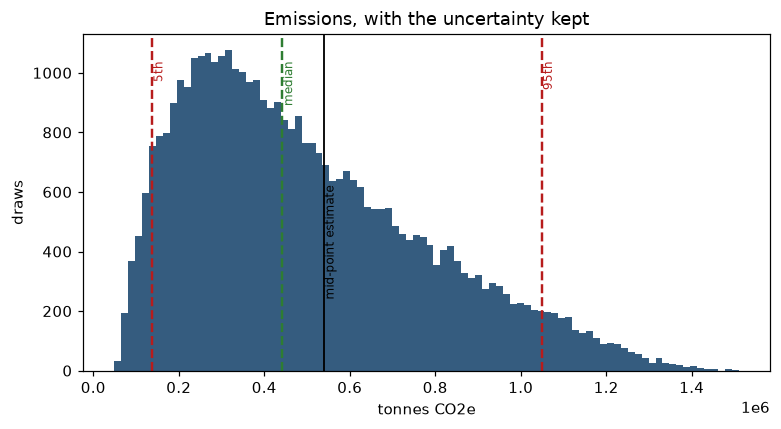

  5th percentile :        138,340 t CO2e
  median         :        442,039 t CO2e
  95th percentile:      1,049,576 t CO2e

  the 90% interval spans a factor of 7.6


In [10]:
AREA_REL_ERR = 0.10        # classification accuracy on the burnt/unburnt call

samples, qs = E.monte_carlo_emissions(
    area_ha_range   = (BURNT_HA * (1 - AREA_REL_ERR), BURNT_HA * (1 + AREA_REL_ERR)),
    fuel_load_range = E.FIRE_PARAMETERS_INDICATIVE["fuel_load_t_per_ha"][:2],
    combustion_range= E.FIRE_PARAMETERS_INDICATIVE["combustion_factor"][:2],
    ef_co2_range    = E.FIRE_PARAMETERS_INDICATIVE["ef_co2_g_per_kg"][:2],
    n=40_000,
)
p05, p50, p95 = qs[0.05], qs[0.5], qs[0.95]

fig, ax = plt.subplots(figsize=(7.2, 4))
ax.hist(samples, bins=90, color="#123F69", alpha=0.85)
for v, lab, c in [(p05, "5th", "#B71C1C"), (p50, "median", "#2E7D32"), (p95, "95th", "#B71C1C")]:
    ax.axvline(v, color=c, lw=1.6, ls="--")
    ax.text(v, ax.get_ylim()[1] * 0.92, f" {lab}", color=c, fontsize=8, rotation=90, va="top")
ax.axvline(point, color="k", lw=1.2)
ax.text(point, ax.get_ylim()[1] * 0.55, " mid-point estimate", fontsize=8, rotation=90, va="top")
ax.set_xlabel("tonnes CO2e"); ax.set_ylabel("draws"); ax.set_title("Emissions, with the uncertainty kept")
plt.tight_layout(); plt.show()

print(f"  5th percentile : {p05:14,.0f} t CO2e")
print(f"  median         : {p50:14,.0f} t CO2e")
print(f"  95th percentile: {p95:14,.0f} t CO2e")
print(f"\n  the 90% interval spans a factor of {p95/p05:.1f}")

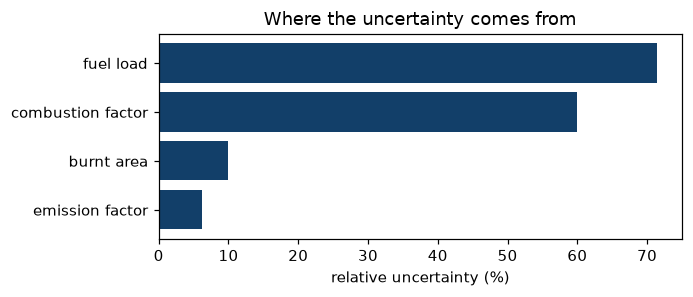

  fuel load              71.4%   ( 57.7% of the variance)
  combustion factor      60.0%   ( 40.7% of the variance)
  burnt area             10.0%   (  1.1% of the variance)
  emission factor         6.2%   (  0.4% of the variance)
  combined (quadrature)   94.0%

  The satellite contributes the SMALLEST term. Buying a better sensor
  would barely move this answer; better fuel-load data would.


In [11]:
# Quadrature, and where the variance actually comes from.
def rel_halfwidth(lo, hi):
    '''Relative half-width of a uniform range about its mid-point.'''
    return (hi - lo) / (hi + lo)

contrib = {
    "burnt area":        AREA_REL_ERR,
    "fuel load":         rel_halfwidth(*E.FIRE_PARAMETERS_INDICATIVE["fuel_load_t_per_ha"][:2]),
    "combustion factor": rel_halfwidth(*E.FIRE_PARAMETERS_INDICATIVE["combustion_factor"][:2]),
    "emission factor":   rel_halfwidth(*E.FIRE_PARAMETERS_INDICATIVE["ef_co2_g_per_kg"][:2]),
}
combined = E.propagate_quadrature(contrib)

order = sorted(contrib.items(), key=lambda kv: kv[1])
fig, ax = plt.subplots(figsize=(6.4, 2.8))
ax.barh([k for k, _ in order], [v * 100 for _, v in order], color="#123F69")
ax.set_xlabel("relative uncertainty (%)"); ax.set_title("Where the uncertainty comes from")
plt.tight_layout(); plt.show()

for k, v in order[::-1]:
    print(f"  {k:20s} {v*100:6.1f}%   ({v**2/combined**2*100:5.1f}% of the variance)")
print(f"  {'combined (quadrature)':20s} {combined*100:6.1f}%")
print()
print("  The satellite contributes the SMALLEST term. Buying a better sensor")
print("  would barely move this answer; better fuel-load data would.")

## 8. From tonnes to dollars, and the punchline

Now price it. Use the ratings-driven price dispersion from the lecture: high-rated
afforestation credits above USD 35, lower-rated equivalents below USD 20 — Sylvera's own
published figures, and therefore an industry claim rather than an independent estimate.

The comparison to make is not "how many dollars". It is between **the width of your
measurement interval** and **the width of the price signal you are trying to trade on**.

In [12]:
PRICE_LOW, PRICE_HIGH = 20.0, 35.0

print(f"{'':22s} {'low price':>16s} {'high price':>16s}")
print("-" * 56)
for lab, t in [("5th percentile", p05), ("median", p50), ("95th percentile", p95)]:
    print(f"{lab:22s} {t*PRICE_LOW:16,.0f} {t*PRICE_HIGH:16,.0f}")
print()

measurement_spread = (p95 - p05) / p95
price_spread = (PRICE_HIGH - PRICE_LOW) / PRICE_HIGH
print(f"  measurement interval width : {measurement_spread*100:5.1f}%  (p95 to p05)")
print(f"  price dispersion           : {price_spread*100:5.1f}%  (USD 35 to USD 20)")
print()
if measurement_spread > price_spread:
    print("  Your measurement uncertainty is WIDER than the price signal.")
    print("  Any claim to rank two projects on tonnage alone is not supported")
    print("  by this evidence. That is a finding, and it should be reported as one.")
else:
    print("  The price signal exceeds the measurement interval, so a ranking is defensible.")

                              low price       high price
--------------------------------------------------------
5th percentile                2,766,797        4,841,894
median                        8,840,776       15,471,358
95th percentile              20,991,515       36,735,151

  measurement interval width :  86.8%  (p95 to p05)
  price dispersion           :  42.9%  (USD 35 to USD 20)

  Your measurement uncertainty is WIDER than the price signal.
  Any claim to rank two projects on tonnage alone is not supported
  by this evidence. That is a finding, and it should be reported as one.


## 9. What the satellite cannot settle

Everything so far measures **what happened**. A carbon credit is a claim about what *would
have* happened otherwise. No instrument observes a counterfactual.

The standard empirical response is a **matched control**: find pixels that resembled the
project area before the event, were not in the project area, and see what happened to them.
The difference in differences is your estimate of the effect.

Run it below, then read the caveat, which matters more than the code.

In [13]:
burnt_sel   = np.isfinite(sev) & (sev >= 3)          # moderate-high and above
control_pool = np.isfinite(sev) & (sev == 0)         # unburnt

if burnt_sel.sum() > 50 and control_pool.sum() > 50:
    # Match on pre-event NBR, so treated and control looked alike beforehand.
    bins = np.linspace(np.nanpercentile(nbr_pre, 1), np.nanpercentile(nbr_pre, 99), 21)
    treated_hist, _ = np.histogram(nbr_pre[burnt_sel], bins=bins)
    ctrl_idx = []
    for b in range(len(bins) - 1):
        want = treated_hist[b]
        if want == 0:
            continue
        pool = np.flatnonzero(control_pool.ravel() &
                              (nbr_pre.ravel() >= bins[b]) & (nbr_pre.ravel() < bins[b + 1]))
        if pool.size:
            ctrl_idx.append(rng.choice(pool, size=min(want, pool.size), replace=False))
    ctrl_idx = np.concatenate(ctrl_idx) if ctrl_idx else np.array([], dtype=int)

    t_pre,  t_post  = nbr_pre[burnt_sel].mean(),  nbr_post[burnt_sel].mean()
    c_pre,  c_post  = nbr_pre.ravel()[ctrl_idx].mean(), nbr_post.ravel()[ctrl_idx].mean()
    did = (t_post - t_pre) - (c_post - c_pre)

    print(f"  matched control pixels : {ctrl_idx.size:,}")
    print(f"  {'':10s} {'pre':>9s} {'post':>9s} {'change':>9s}")
    print(f"  {'treated':10s} {t_pre:9.3f} {t_post:9.3f} {t_post-t_pre:+9.3f}")
    print(f"  {'control':10s} {c_pre:9.3f} {c_post:9.3f} {c_post-c_pre:+9.3f}")
    print(f"  {'difference':10s} {'':9s} {'':9s} {did:+9.3f}   <- difference in differences")
else:
    print("  Not enough treated or control pixels in this scene for a matched comparison.")

  matched control pixels : 155,711
                   pre      post    change
  treated        0.478    -0.131    -0.609
  control        0.476     0.505    +0.028
  difference                        -0.638   <- difference in differences


> **The caveat that matters.** What you just computed is *attribution*: the change is
> attributable to the event and not to something affecting the whole landscape. That is real,
> and it is useful.
>
> It is **not additionality**. Additionality asks whether the project caused an outcome that
> would not have occurred without the finance. A matched control cannot answer that, because
> the matching variable is observable and the decision to enrol a project is not. If the
> landholder would have protected the forest anyway, every pixel here still looks identical.
>
> This is the weakest link in every carbon credit, it sits at step 6 of the chain, and no
> improvement in sensor technology touches it.

## 10. What to report

A result that cannot be reproduced is an opinion. Record the provenance alongside the number,
every time — and note that this record is what an assurance provider would ask for first.

In [14]:
import datetime, json

record = {
    "question": "Tonnes CO2e lost to fire within the area of interest",
    "area_of_interest": {"name": AOI_NAME, "bbox": [round(v, 5) for v in BBOX],
                         "half_width_km": HALF_WIDTH_KM},
    "imagery": {"source": pre_label if pre_label == post_label else f"{pre_label} / {post_label}",
                "collection": E.STAC_COLLECTION, "resolution_m": RESOLUTION_M,
                "pre_window": [PRE_START, PRE_END], "post_window": [POST_START, POST_END]},
    "processing": {"reflectance_offset": -1000, "reflectance_scale": 10000,
                   "mask": "SCL, joint over both dates",
                   "usable_fraction": round(float(mask.mean()), 4),
                   "severity_breaks": "FIREMON convention (calibrated for conifer, "
                                      "applied here to a different system)"},
    "result": {"burnt_area_ha": round(BURNT_HA, 1),
               "tCO2e_p05": round(p05), "tCO2e_median": round(p50), "tCO2e_p95": round(p95),
               "interval_factor": round(p95 / p05, 2)},
    "parameters": {k: list(v[:2]) for k, v in E.FIRE_PARAMETERS_INDICATIVE.items()},
    "parameter_status": "INDICATIVE RANGES, NOT SOURCED. Replace before any external use.",
    "generated": datetime.datetime.now().isoformat(timespec="seconds"),
}
print(json.dumps(record, indent=2))

{
  "question": "Tonnes CO2e lost to fire within the area of interest",
  "area_of_interest": {
    "name": "blue-mountains",
    "bbox": [
      150.13757,
      -33.83514,
      150.46243,
      -33.56486
    ],
    "half_width_km": 15.0
  },
  "imagery": {
    "source": "live 2019-11-06 (cloud 0%) / live 2020-03-20 (cloud 0%)",
    "collection": "sentinel-2-c1-l2a",
    "resolution_m": 20,
    "pre_window": [
      "2019-09-01",
      "2019-11-15"
    ],
    "post_window": [
      "2020-02-01",
      "2020-04-15"
    ]
  },
  "processing": {
    "reflectance_offset": -1000,
    "reflectance_scale": 10000,
    "mask": "SCL, joint over both dates",
    "usable_fraction": 0.6099,
    "severity_breaks": "FIREMON convention (calibrated for conifer, applied here to a different system)"
  },
  "result": {
    "burnt_area_ha": 17817.0,
    "tCO2e_p05": 138340,
    "tCO2e_median": 442039,
    "tCO2e_p95": 1049576,
    "interval_factor": 7.59
  },
  "parameters": {
    "fuel_load_t_per_ha": [

## Core exercises

**C1 — Report the result properly.** Write the finding as three sentences suitable for an
investment committee. One sentence for the estimate, one for the uncertainty, one for what
would have to be true for the estimate to be wrong. No hedging adverbs.

**C2 — Price the threshold.** Re-run sections 5 to 7 with the moderate-high break moved from
0.44 to 0.35 and then to 0.55. Report the three burnt areas and the three median tonnages.
State how much of the final answer is a property of the fire and how much is a property of
your choice.

**C3 — Find the binding constraint.** From the quadrature panel, identify which parameter you
would spend money to improve first, and estimate how much the 90 per cent interval would narrow
if you halved its uncertainty. Then answer the question your client will ask: is that worth
doing?

## Stretch exercises

**S1 — Date the disturbance.** Pull every scene over the area for eighteen months, mask each
one, build an NBR time series over the burnt polygon, and identify the acquisition on which the
drop occurs. How precisely can you date the event, and what sets that precision?

**S2 — Recovery, and what it means for permanence.** Extend the series two years past the
event. Fit a simple recovery curve to mean NBR. Then argue, in a paragraph, whether NBR
recovery is evidence of *carbon* recovery. Consider what eucalypt epicormic resprouting does to
a near-infrared signal versus what it does to a carbon stock.

**S3 — Swap the instrument.** Repeat the burnt-area estimate using Sentinel-1 radar instead of
optical imagery. Compare the areas. Radar sees through smoke and cloud, which is decisive for
a fire that is still burning, but responds to structure rather than chlorophyll. Which would
you trust for an insurance claim, and why?

**S4 — Break the pair.** Deliberately introduce a one-pixel shift between the pre and post
scenes with `np.roll`. Recompute the burnt area. Report the error a single pixel of
misregistration causes, and relate it to the edge density of your particular landscape.

## Where this leaves you

You have taken a satellite image and produced a dollar exposure with an interval attached. Four
things are worth carrying forward.

1. **The satellite was the smallest source of uncertainty.** The literature parameters
   dominated. Analysts routinely invert this, and spend on resolution rather than on
   calibration.
2. **The masking step changed the answer materially**, and it is the step most often skipped.
3. **A threshold is a modelling decision**, and it moves the result as much as the physics does.
4. **The counterfactual is not observable.** Steps 1 to 5 of the chain are measurement. Step 6
   is inference about a world that did not happen, and that is where the money is.

For Assessment 2, the case studies that land are the ones that carry an interval to the end and
say plainly what would falsify the conclusion.